<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%204/01_policy_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Policy Evaluation
**Week 4 | Dynamic Programming**

**Policy Evaluation** answers: *How good is a given policy π?*

We iteratively apply the Bellman expectation equation until V converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- Reuse Grid World from Week 3 ----
class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size = size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits = {(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        """Return list of (prob, next_s, reward, done)."""
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr)); nc = max(0, min(self.size-1, c+dc))
        ns = nr*self.size + nc
        if (nr,nc) == self.goal:       return [(1.0, ns, +10.0, True)]
        if (nr,nc) in self.pits:       return [(1.0, ns,  -5.0, True)]
        return [(1.0, ns, -0.1, False)]

env = GridWorld()

In [2]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    Iterative policy evaluation.
    policy: array of shape (n_states, n_actions) — action probabilities.
    Returns V: array of shape (n_states,)
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]
    for iteration in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[s]))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        history.append(V.copy())
        if delta < theta:
            print(f"Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break
    return V, history

In [3]:
# Uniform random policy
n_s, n_a = env.n_states(), env.n_actions()
uniform_policy = np.ones((n_s, n_a)) / n_a

V, history = policy_evaluation(env, uniform_policy)

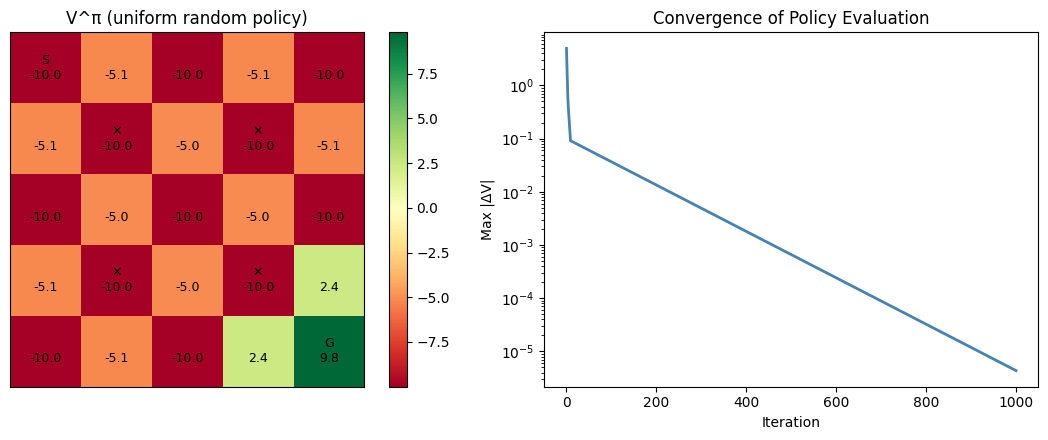

In [5]:
# Visualise final value function
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap
im = axes[0].imshow(V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for r in range(5):
    for c in range(5):
        label = ''
        if (r,c)==env.goal: label='G'
        elif (r,c)==env.start: label='S'
        elif (r,c) in env.pits: label='✕'
        axes[0].text(c, r, f'{label}\n{V[r*5+c]:.1f}', ha='center', va='center', fontsize=9)
axes[0].set_title('V^π (uniform random policy)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Convergence curve
max_delta = [np.max(np.abs(history[i+1]-history[i])) for i in range(len(history)-1)]
axes[1].semilogy(max_delta, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Convergence of Policy Evaluation')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Try γ=0.5, γ=0.9, γ=0.999. How does the value function shape change?
2. Create a policy that always moves RIGHT. Evaluate it. What happens to states on the rightmost column?
3. **Challenge**: implement **in-place** policy evaluation (update V[s] immediately instead of V_new). Does it converge faster?

### Exercise 1 & 2 Analysis

**1. Effect of changing $\gamma$:**
* **$\gamma = 0.5$**: The values drop off extremely fast. Only states immediately next to the Goal (G) or Pits (X) have significant values. The agent is very short-sighted.
* **$\gamma = 0.999$**: The values spread evenly across the grid. The agent cares deeply about the distant Goal, meaning even the starting state `(0,0)` has a high value because the agent is willing to wait.

**2. Policy that always moves RIGHT (Action 3):**
* If the agent always moves Right, it will hit the right wall (column 4). Since the action `RIGHT` at the rightmost column just bounces the agent back to the same state with a `-0.1` step cost, the agent gets stuck infinitely taking step costs.
* Because of the discount factor, this infinite loop of `-0.1` costs converges to a negative value. The rightmost states (except the goal) become highly undesirable under this deterministic policy.

In [6]:
# ==========================================
# Exercise 3: Challenge - In-Place Policy Evaluation
# ==========================================
def in_place_policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=1000):
    """
    In-place iterative policy evaluation.
    Updates V[s] immediately using the most recently updated values of other states.
    """
    V = np.zeros(env.n_states())
    history = [V.copy()]

    for iteration in range(max_iter):
        delta = 0.0
        for s in range(env.n_states()):
            v = 0.0
            for a in range(env.n_actions()):
                for prob, ns, reward, done in env.transitions(s, a):
                    # Uses the updated V[ns] if it was already processed in this sweep!
                    v += policy[s, a] * prob * (reward + (0 if done else gamma * V[ns]))

            # Calculate delta and update IN-PLACE
            delta = max(delta, abs(v - V[s]))
            V[s] = v

        history.append(V.copy())
        if delta < theta:
            print(f"In-Place Converged in {iteration+1} iterations (Δ={delta:.2e})")
            break

    return V, history

print("--- Convergence Comparison ---")
_, hist_std = policy_evaluation(env, uniform_policy, gamma=0.99)
_, hist_in_place = in_place_policy_evaluation(env, uniform_policy, gamma=0.99)

print(f"\nConclusion: In-place evaluation converges in {len(hist_in_place)-1} iterations compared to {len(hist_std)-1} for standard.")
print("It is faster because it uses 'fresher' data immediately during the state sweep.")

--- Convergence Comparison ---
In-Place Converged in 60 iterations (Δ=9.69e-07)

Conclusion: In-place evaluation converges in 60 iterations compared to 1000 for standard.
It is faster because it uses 'fresher' data immediately during the state sweep.
